# Parte 1 - Word Embeddings com Gensim
## Objetivo: Comparar Word2Vec, GloVe e FastText em tarefas de similaridade e analogias.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
print("Setup completo!")

Setup completo!


Parte 1 - Word Embeddings com Gensim

Objetivo: Comparar Word2Vec, GloVe e FastText em tarefas de similaridade e analogias.

In [2]:
import gensim
import gensim.downloader as api

print("Modelos disponíveis no Gensim:")

for model_name in list(api.info()['models'].keys())[:5]: # Mostrar apenas 5
    print(f" - {model_name}")

print("\n" + "="*60)
print("CARREGANDO MODELOS (pode levar alguns minutos)...")
print("="*60)

# [TODO 1.1.1] Carregue o modelo Word2Vec do Google News (300 dimensões)
# Dica: use api.load("word2vec-google-news-300")

word2vec = api.load("word2vec-google-news-300")

print("\n1. Word2Vec carregado!")

Modelos disponíveis no Gensim:
 - fasttext-wiki-news-subwords-300
 - conceptnet-numberbatch-17-06-300
 - word2vec-ruscorpora-300
 - word2vec-google-news-300
 - glove-wiki-gigaword-50

CARREGANDO MODELOS (pode levar alguns minutos)...

1. Word2Vec carregado!


In [3]:
# [TODO 1.1.2] Carregue o modelo GloVe treinado no Twitter (200 dimensões)
# Dica: use api.load("glove-twitter-200")

glove = api.load("glove-twitter-200")

print("2. GloVe carregado!")

2. GloVe carregado!


In [4]:
# [TODO 1.1.3] Carregue o modelo FastText treinado na Wikipedia (300 dimensões)
# Dica: use api.load("fasttext-wiki-news-subwords-300")

fasttext = api.load("fasttext-wiki-news-subwords-300")

print("3. FastText carregado!")

print("Todos os modelos carregados com sucesso!")

3. FastText carregado!
Todos os modelos carregados com sucesso!


Questão 1.2. Similaridade de Palavras

In [18]:
# Lista de pares de palavras para testar

word_pairs = [
("carro", "automóvel"),
("feliz", "contente"),
("gato", "cão"),
("rei", "rainha"),
("computador", "teclado"),
("amor", "ódio"),
("rápido", "veloz"),
("bom", "mau")
]

# Dicionário para armazenar resultados
results = {
'word1': [],
'word2': [],
'similarity_word2vec': [],
'similarity_glove': [],
'similarity_fasttext': []
}

In [19]:
# [TODO 1.2.1] Complete a função para calcular similaridade com tratamento de erros

def get_similarity(model, word1, word2, model_name):
    """
    Retorna a similaridade entre word1 e word2 usando o modelo.
    Se alguma palavra não for encontrada, retorna NaN e imprime aviso.
    """
    try:
        # [TODO] Use o método similarity do modelo
        similarity = model.similarity(word1, word2)
        return similarity
    
    except KeyError as e:
        print(f" ⚠ {model_name}: palavra '{e}' não encontrada")
        return np.nan

# Calcular similaridades
for w1, w2 in word_pairs:
    results['word1'].append(w1)
    results['word2'].append(w2)

    # [TODO 1.2.2] Calcule similaridade para word2vec
    sim_w2v = get_similarity(word2vec, w1, w2, "Word2Vec")
    results['similarity_word2vec'].append(sim_w2v)
    
    # [TODO 1.2.3] Calcule similaridade para glove
    sim_glove = get_similarity(glove, w1, w2, "GloVe")
    results['similarity_glove'].append(sim_glove)
    
    # [TODO 1.2.4] Calcule similaridade para fasttext
    sim_ft = get_similarity(fasttext, w1, w2, "FastText")
    results['similarity_fasttext'].append(sim_ft)

# Criar DataFrame
df_similarities = pd.DataFrame(results)
print("\n" + "="*60)
print("SIMILARIDADES ENTRE PARES DE PALAVRAS")
print("="*60)
print(df_similarities.to_string())

 ⚠ Word2Vec: palavra '"Key 'automóvel' not present"' não encontrada
 ⚠ FastText: palavra '"Key 'automóvel' not present"' não encontrada
 ⚠ Word2Vec: palavra '"Key 'contente' not present"' não encontrada
 ⚠ Word2Vec: palavra '"Key 'cão' not present"' não encontrada
 ⚠ FastText: palavra '"Key 'cão' not present"' não encontrada
 ⚠ Word2Vec: palavra '"Key 'rainha' not present"' não encontrada
 ⚠ FastText: palavra '"Key 'rainha' not present"' não encontrada
 ⚠ Word2Vec: palavra '"Key 'computador' not present"' não encontrada
 ⚠ Word2Vec: palavra '"Key 'ódio' not present"' não encontrada
 ⚠ FastText: palavra '"Key 'ódio' not present"' não encontrada
 ⚠ Word2Vec: palavra '"Key 'veloz' not present"' não encontrada

SIMILARIDADES ENTRE PARES DE PALAVRAS
        word1      word2  similarity_word2vec  similarity_glove  similarity_fasttext
0       carro  automóvel                  NaN          0.236243                  NaN
1       feliz   contente                  NaN          0.418507            

Muitas das palavras não estão presentes nos dicionários dos modelos, por estes serem maioritariamente em inglês. Para obter melhores resultados deveriamos usar um modelo de embedding treinado em português.

In [20]:
# Questão 1.2.5:
# Qual par de palavras apresentou a MAIOR similaridade média entre os três modelos?

sim_cols = ["similarity_word2vec", "similarity_glove", "similarity_fasttext"]
df_q = df_similarities.drop_duplicates(subset=["word1", "word2"], keep="last").copy()
# média só sobre modelos com valor (NaN = palavra fora do vocabulário)
df_q["mean_3_models"] = df_q[sim_cols].mean(axis=1)
df_q = df_q[df_q[sim_cols].notna().any(axis=1)]

best = df_q.loc[df_q["mean_3_models"].idxmax()]
print(f"Par com maior similaridade média: ({best['word1']!r}, {best['word2']!r})")
print(f"Média = {best['mean_3_models']:.6f}")
print("Por modelo:", best[sim_cols].to_dict())


Par com maior similaridade média: ('computador', 'teclado')
Média = 0.612613
Por modelo: {'similarity_word2vec': nan, 'similarity_glove': 0.6044475436210632, 'similarity_fasttext': 0.6207780241966248}


A resposta a esta pergunta, tendo em conta os resultados, não está presente em nenhuma das alíneas. No entanto este resultado está longe de corresponder à realidade devido ao problema levantado acima.

Vamos fazer um teste com as mesmas palavras mas em inglês, para ver se os resultados melhoram.

In [21]:
word_pairs_english = [
("car", "automobile"),
("happy", "glad"),
("cat", "dog"),
("king", "queen"),
("computer", "keyboard"),
("love", "hate"),
("fast", "quick"),
("good", "bad")
]

In [23]:
# Teste com palavras em inglês
results_english = {
'word1': [],
'word2': [],
'similarity_word2vec': [],
'similarity_glove': [],
'similarity_fasttext': []
}

# Calcular similaridades
for w1, w2 in word_pairs_english:
    results_english['word1'].append(w1)
    results_english['word2'].append(w2)

    sim_w2v = get_similarity(word2vec, w1, w2, "Word2Vec")
    results_english['similarity_word2vec'].append(sim_w2v)

    sim_glove = get_similarity(glove, w1, w2, "GloVe")
    results_english['similarity_glove'].append(sim_glove)

    sim_ft = get_similarity(fasttext, w1, w2, "FastText")
    results_english['similarity_fasttext'].append(sim_ft)

# Criar DataFrame
df_similarities_english = pd.DataFrame(results_english)
print("\n" + "="*60)
print("SIMILARIDADES ENTRE PARES DE PALAVRAS EM INGLÊS")
print("="*60)
print(df_similarities_english.to_string())


SIMILARIDADES ENTRE PARES DE PALAVRAS EM INGLÊS
      word1       word2  similarity_word2vec  similarity_glove  similarity_fasttext
0       car  automobile             0.583837          0.456711             0.779027
1     happy        glad             0.740889          0.595591             0.757904
2       cat         dog             0.760946          0.832430             0.750230
3      king       queen             0.651096          0.688930             0.770425
4  computer    keyboard             0.396392          0.634711             0.609826
5      love        hate             0.600396          0.684241             0.740020
6      fast       quick             0.570161          0.696230             0.731268
7      good         bad             0.719005          0.798351             0.850309


In [24]:
sim_cols = ["similarity_word2vec", "similarity_glove", "similarity_fasttext"]
df_q = df_similarities_english.drop_duplicates(subset=["word1", "word2"], keep="last").copy()
# média só sobre modelos com valor (NaN = palavra fora do vocabulário)
df_q["mean_3_models"] = df_q[sim_cols].mean(axis=1)
df_q = df_q[df_q[sim_cols].notna().any(axis=1)]

best = df_q.loc[df_q["mean_3_models"].idxmax()]
print(f"Par com maior similaridade média: ({best['word1']!r}, {best['word2']!r})")
print(f"Média = {best['mean_3_models']:.6f}")
print("Por modelo:", best[sim_cols].to_dict())


Par com maior similaridade média: ('good', 'bad')
Média = 0.789222
Por modelo: {'similarity_word2vec': 0.7190051078796387, 'similarity_glove': 0.7983508110046387, 'similarity_fasttext': 0.850308895111084}


Assim já obtemos melhores resultados, apesar de parecerem incorretos de certa forma. Seria de esperar que 'car' e 'automobile' fossem semelhantes, mas estão distantes. Enquanto isso, curiosamente, os mais semelhantes são opostos - 'good' e 'bad'.

Questão 1.2.6:

Porque é que "amor-ódio" e "bom-mau" apresentam similaridades altas se são opostos?

• A) Porque os modelos não conseguem distinguir antónimos

• B) Porque palavras opostas aparecem em contextos semelhantes

• C) Porque há um erro nos embeddings

• D) Porque são palavras curtas

Resposta: B.

Os embeddings aprendem vetores a partir de contextos. Então palavras que aparecem em frases e padrões parecidos ficam com vetores próximos, mais semelhantes. É o caso destes antónimos.

# Daqui para a frente vamos usar o df_similarities_english para obter melhores resultados.

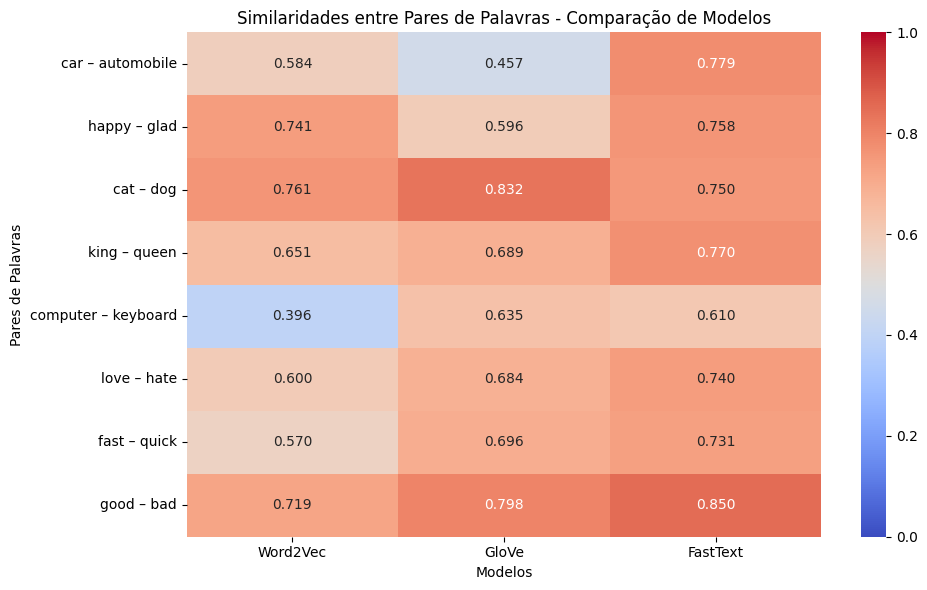

In [25]:
# Questão 1.3. Visualização de Similaridades

# [TODO 1.3.1] Crie um heatmap das similaridades usando seaborn
# Use o DataFrame df_similarities_english com as colunas de similaridade
plt.figure(figsize=(10, 6))

sim_cols = ["similarity_word2vec", "similarity_glove", "similarity_fasttext"]
df_plot = df_similarities_english.drop_duplicates(subset=["word1", "word2"], keep="last")

# Crie uma matriz apenas com as colunas de similaridade
similarity_matrix = df_plot[sim_cols].copy()
similarity_matrix.index = df_plot["word1"] + " – " + df_plot["word2"]
similarity_matrix.columns = ["Word2Vec", "GloVe", "FastText"]

# [TODO] Use sns.heatmap para visualizar
# Dica: use annot=True para mostrar os valores, cmap='coolwarm', vmin=0, vmax=1
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=0,
    vmax=1,
)

plt.title('Similaridades entre Pares de Palavras - Comparação de Modelos')
plt.ylabel('Pares de Palavras')
plt.xlabel('Modelos')
plt.tight_layout()
plt.show()

In [26]:
# Testar analogias famosas

analogies = [
('rei', 'homem', 'mulher'), # rei - homem + mulher = ?
('paris', 'frança', 'alemanha'), # paris - frança + alemanha = ?
('correr', 'correu', 'comeu'), # correr - correu + comeu = ? (verbos)
]

print("\n" + "="*60)
print("TESTAR ANALOGIAS")
print("="*60)

# [TODO 1.4.1] Complete o loop para testar analogias nos três modelos
for model_name, model in [('Word2Vec', word2vec), ('GloVe', glove), ('FastText', fasttext)]:
    print(f"\n📊 {model_name}:")
    print("-" * 40)

    for a, b, c in analogies:  # analogia: a - b + c ≈ ?
        # Gensim: vetor ≈ vec(a) - vec(b) + vec(c)  →  positive=[a, c], negative=[b]
        positive = [a, c]
        negative = [b]
        try:
            result = model.most_similar(positive=positive, negative=negative, topn=5)
            print(f"\n {a} - {b} + {c} ≈ ?")
            for word, score in result:
                print(f"  → {word}: {score:.4f}")
        except KeyError as e:
            print(f" Palavra não encontrada: {e}")


TESTAR ANALOGIAS

📊 Word2Vec:
----------------------------------------
 Palavra não encontrada: "Key 'mulher' not present in vocabulary"
 Palavra não encontrada: "Key 'alemanha' not present in vocabulary"
 Palavra não encontrada: "Key 'correr' not present in vocabulary"

📊 GloVe:
----------------------------------------

 rei - homem + mulher ≈ ?
  → rainha: 0.5743
  → vivi: 0.4985
  → tia: 0.4846
  → reis: 0.4790
  → diva: 0.4576

 paris - frança + alemanha ≈ ?
  → london: 0.5894
  → berlin: 0.5779
  → france: 0.5676
  → amsterdam: 0.5487
  → germany: 0.5234

 correr - correu + comeu ≈ ?
  → comer: 0.6305
  → hora: 0.5255
  → tomar: 0.5175
  → beber: 0.5129
  → parar: 0.5117

📊 FastText:
----------------------------------------

 rei - homem + mulher ≈ ?
  → ente: 0.5816
  → repente: 0.5687
  → achei: 0.5643
  → assa: 0.5620
  → deve: 0.5573
 Palavra não encontrada: "Key 'alemanha' not present in vocabulary"
 Palavra não encontrada: "Key 'comeu' not present in vocabulary"


Questão 1.4. Qual modelo apresentou o melhor resultado para a analogia "rei - homem + mulher"?

• A) Word2Vec

• B) GloVe

• C) FastText

• D) Todos apresentaram o mesmo resultado

O GloVe foi o único modelo a apresentar bons resultados, pelos problemas já referidos. Portanto alínea B. 

In [27]:
# Questão 1.5. Palavras Fora do Vocabulário (OOV).
# Testando palavras que podem não estar no vocabulário
test_words = [
"neural",
"transformers",
"chatgpt",
"pós-modernismo" # Palavra com acento
]

print("\n" + "="*60)
print("TESTANDO PALAVRAS FORA DO VOCABULÁRIO (OOV)")
print("="*60)

# [TODO 1.5.1] Complete o código para testar palavras OOV
for word in test_words:
    print(f"\n Palavra: '{word}'")

    for model_name, model in [('Word2Vec', word2vec), ('GloVe', glove), ('FastText', fasttext)]:
        try:
            # [TODO] Tente acessar o vetor da palavra
            vector = model[word]
            print(f" ✓ {model_name}: encontrada (vetor dimensão {len(vector)})")

            # [TODO] Encontre palavras similares (top 3)
            similar = model.most_similar(word, topn=3)
            print(f" Palavras similares: {[s[0] for s in similar]}")
        
        except KeyError:
            print(f" ✗ {model_name}: NÃO encontrada")
            
            # [TODO] Para FastText, tente usar hasattr para verificar se pode gerar vetor via subwords
            if model_name == 'FastText' and hasattr(model, 'vectors_ngrams'):
                try:
                    # Tenta obter via subwords
                    vector = model.word_vec(word, use_norm=True)
                    print(f" ✓ FastText (subwords) conseguiu gerar vetor!")
                except Exception:
                    pass


TESTANDO PALAVRAS FORA DO VOCABULÁRIO (OOV)

 Palavra: 'neural'
 ✓ Word2Vec: encontrada (vetor dimensão 300)
 Palavras similares: ['neuronal', 'neurons', 'neural_circuits']
 ✓ GloVe: encontrada (vetor dimensão 200)
 Palavras similares: ['pathways', 'adaptive', 'mechanisms']
 ✓ FastText: encontrada (vetor dimensão 300)
 Palavras similares: ['neuronal', 'non-neural', 'cortical']

 Palavra: 'transformers'
 ✓ Word2Vec: encontrada (vetor dimensão 300)
 Palavras similares: ['transformer', 'substations', '##KV']
 ✓ GloVe: encontrada (vetor dimensão 200)
 Palavras similares: ['transformer', 'avengers', 'terminator']
 ✓ FastText: encontrada (vetor dimensão 300)
 Palavras similares: ['transformer', 'inverters', 'autotransformers']

 Palavra: 'chatgpt'
 ✗ Word2Vec: NÃO encontrada
 ✗ GloVe: NÃO encontrada
 ✗ FastText: NÃO encontrada

 Palavra: 'pós-modernismo'
 ✗ Word2Vec: NÃO encontrada
 ✗ GloVe: NÃO encontrada
 ✗ FastText: NÃO encontrada


Questão 1.5.2. Qual modelo conseguiu lidar melhor com a palavra "chatgpt" (neologismo)?

• A) Word2Vec

• B) GloVe

• C) FastText

• D) Nenhum conseguiu

Resposta: D. Nenhum conseguiu, apenas conseguiram para as palavras que existem nos dicionários em inglês ('neural' e 'transformers').

Questão 1.5.3. Por que o FastText consegue gerar vetores para palavras desconhecidas?

• A) Porque tem um vocabulário maior

• B) Porque usa subpalavras (n-grams de caracteres)

• C) Porque é treinado com mais dados

• D) Porque usa redes neurais mais profundas

Resposta: B.